### Working w/ Larger Example (Multiclass Classification)

When you have more than 2 classes as a target, it's known as **Multiclass Classification**.
- Which is, if you have more than 2 either that's 3 or even 100 of target, it's called multiclass classification.

In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

#### Understanding Data

In [4]:
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [12]:
# Data shape
(train_data[69].shape, train_labels[69].shape)

((28, 28), ())

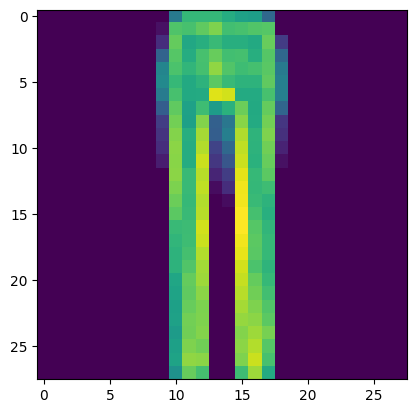

In [17]:
# Visualize the data
import matplotlib.pyplot as plt
plt.imshow(train_data[69])

In [22]:
# Check sample label
train_labels[69]

np.uint8(1)

In [24]:
# Create Labels
class_name = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
len(class_name)

10

Text(0.5, 1.0, 'Shirt')

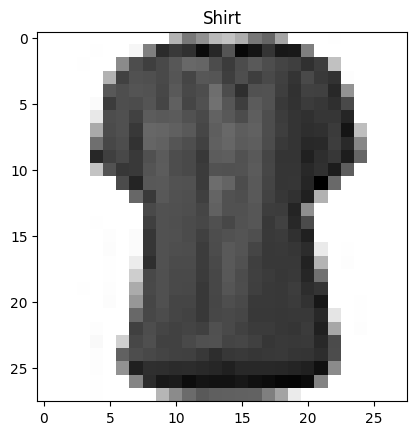

In [27]:
# Plot an example image and its label
index_data = 55
plt.imshow(train_data[index_data], cmap=plt.cm.binary)
plt.title(class_name[train_labels[index_data]])

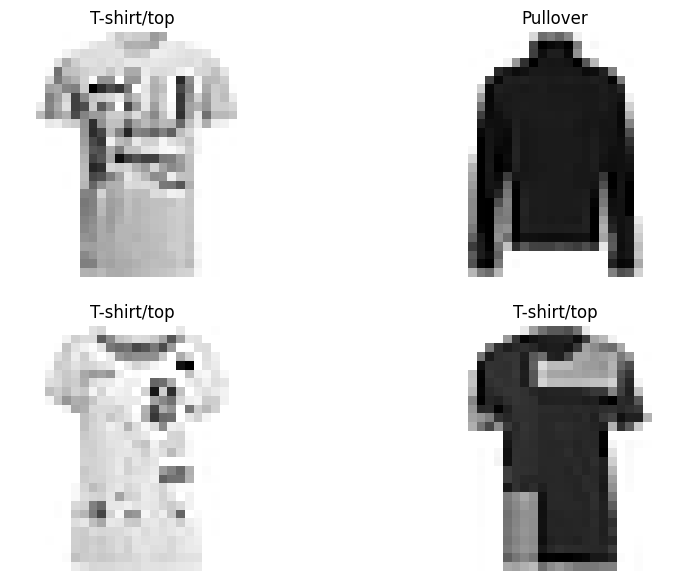

In [31]:
import random as rand
plt.figure(figsize=(10, 7))
for i in range(4):
    ax = plt.subplot(2, 2, i + 1)
    rand_index = rand.choice(range(len(train_data)))
    plt.imshow(train_data[rand_index], cmap=plt.cm.binary)
    plt.title(class_name[train_labels[rand_index]])
    plt.axis(False)

#### Building Multiclass Classification Model
For the model, we use a similiar architecture the latest binary classification model 6 on Course 6, however,
we're going to have to tweak the model, so it can match with our problem. Things we're going to change:
- Input shape: 28x28 (the shape of one train_data)
- Output shape: 10 (one per classes of clothing)
- Loss function: tf.keras.losses.CategoricalCrossentropy()
    - If your labels are one hot encoded, use CategoricalCrossentropy()
    - And if your labels are integer form, use SparseCategoricalCrossentropy()
- Output layer = softmax

In [37]:
# The data need to be flattened first (from 28*28 to None, 784)
flatten_model = tf.keras.Sequential([tf.keras.layers.Flatten(input_shape=(28,28))])
flatten_model.output_shape

c:\Users\Diandra\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


(None, 784)

In [38]:
# Set random seed
tf.random.set_seed(42)

# Create model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Compile Model
model_1.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit Model
non_norm_hist = model_1.fit(train_data, tf.one_hot(train_labels, depth=10), epochs=10, validation_data=(test_data, tf.one_hot(test_labels, depth=10)))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1444 - loss: 2.5619 - val_accuracy: 0.2198 - val_loss: 1.8003
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2387 - loss: 1.7656 - val_accuracy: 0.2922 - val_loss: 1.6944
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2820 - loss: 1.6767 - val_accuracy: 0.2829 - val_loss: 1.6446
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2933 - loss: 1.6348 - val_accuracy: 0.3004 - val_loss: 1.6158
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3003 - loss: 1.6135 - val_accuracy: 0.3171 - val_loss: 1.6026
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3092 - loss: 1.5991 - val_accuracy: 0.3235 - val_loss: 1.5910
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3182 - loss: 1.5893 - val_accuracy: 0.3277 - val_loss: 1.5819
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3241 - loss: 1.5799 - 

In [39]:
model_1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)